In [7]:
import numpy as np
import pandas as pd

# I have used parameters from research papers from-
# Avila-Varela et al., Bull et al., and Fitriani et al., Patel, Lateef et al., Nagma et al.


population_mean_cycle_len = 28.5
population_sd = 4.5
intra_user_sd_min = 1.5
intra_user_sd_max = 5.0
cycle_min, cycle_max = 21, 45

#this is according to patel's data - need to change it to indian teens?

def bmi_irregularity_factor(bmi):
    # This is a placeholder. You would implement the actual logic based on research here.
    # For demonstration, let's assume a simple linear relationship or categories.
    if bmi < 18.5: # Underweight
        return 0.5
    elif bmi >= 25.0: # Overweight/Obese
        return 0.3
    else: # Normal weight
        return -0.2



#lifestyle coefficients - fitrani et al.
sleep_day = 0.8
stress_day = 0.6
exercise_day = -0.4

#compute irregularity probability

def compute_irregularity(bmi, sleep, stress):
    base_irregular_rate = 0.143

    log_odds = np.log(base_irregular_rate / (1 - base_irregular_rate))

    log_odds += bmi_irregularity_factor(bmi)

    if sleep < 6.0:
        log_odds += np.log(2.05)

    if stress > 6.0:
        log_odds += np.log(2.26)

    return 1 / (1 + np.exp(-log_odds))

def lifestyle_shift(sleep, stress, exercise):
    sleep_shift = (7.0 - sleep) * sleep_day

    stress_shift = (stress - 5.0) * stress_day

    exercise_shift = (3.5 - exercise) * exercise_day

    return sleep_shift + stress_shift + exercise_shift

#generate a bunch of simulation of cycles
def simulation_synthetic_cycles(n_users=500, cycles_per_user=12, seed=42):
    np.random.seed(seed)
    records = []

    for user_id in range(n_users):
        personal_mean = np.random.normal(population_mean_cycle_len, population_sd)
        personal_sd = np.random.uniform(intra_user_sd_min, intra_user_sd_max)

        bmi_random = np.random.random()
        if bmi_random < 0.15:
            bmi = np.random.uniform(15.0, 18.4)
        elif bmi_random < 0.75:
            bmi = np.random.uniform(18.5, 24.9)
        else:
            bmi = np.random.uniform(25.0, 35.0)

    #set up random sleep, stress, and exercise hours
        start_sleep = np.random.normal(7.2, 1.1)
        start_stress = np.random.uniform(1.0, 9.0)
        start_exercise = np.random.uniform(0.0, 7.0)

    #for loops for determining length of cycle and each phase
        for cycle_num in range(cycles_per_user):
            sleep = np.clip(start_sleep + np.random.normal(0, 0.6), 3.0, 10.0)
            stress = np.clip(start_stress + np.random.normal(0, 1.5), 1.0, 10.0)
            exercise = np.clip(start_exercise + np.random.normal(0, 0.8), 0.0, 7.0)

            irreg = compute_irregularity(bmi, sleep, stress)
            reg_or_no = np.random.random() < irreg

            life_shift_val = lifestyle_shift(sleep, stress, exercise)

            if reg_or_no:
                if np.random.random() < 0.3:
                    cycle_len = np.random.uniform(cycle_min, 20)
                else:
                    cycle_len = np.random.uniform(36, cycle_max)
            else:
                cycle_len = np.random.normal(personal_mean + life_shift_val, personal_sd)
                cycle_len = np.clip(cycle_len, cycle_min, cycle_max)

            luteal_len = np.clip(np.random.normal(14.0, 1.5), 10, 18)
            follicular_len = max(cycle_len - luteal_len, 5)

            if bmi < 18.5:
                dym_prob = 0.90
            else:
                dym_prob = 0.31

            records.append({
                'user_id': user_id,
                'cycle_no': cycle_num,
                'cycle_len': round(cycle_len, 1),
                'follicular_len': round(follicular_len, 1),
                'luteal_len': round(luteal_len, 1),
                'irreg': int(reg_or_no),
                'bmi': round(bmi, 1),
                'sleep_hrs': round(sleep, 1),
                'stress_lvl': round(stress, 1),
                'exercise_days': round(exercise, 1),
                'dysmenorrhea': int(np.random.random() < dym_prob),
                'p_irregular': round(irreg, 3),
                'source': 'synthetic'
            })
    df = pd.DataFrame(records)
    return df

In [8]:
print('Generating synthetic data with 10 users and 5 cycles per user:')

#1) import and inspect data
synthetic_data = simulation_synthetic_cycles(n_users=500, cycles_per_user=12, seed=42)
display(synthetic_data)
synthetic_data.to_csv('gc_synthetic_cycles.csv', index=False)

Generating synthetic data with 10 users and 5 cycles per user:


,user_id,cycle_no,cycle_len,follicular_len,luteal_len,irreg,bmi,sleep_hrs,stress_lvl,exercise_days,dysmenorrhea,p_irregular,source
0,0,0,26.3,11.9,14.4,0,19.5,7.2,3.8,0.0,0,0.120,synthetic
1,0,1,20.6,5.0,16.2,1,19.5,5.9,3.5,0.0,1,0.219,synthetic
2,0,2,37.5,24.4,13.1,1,19.5,6.9,6.1,0.7,0,0.236,synthetic
3,0,3,30.5,18.3,12.2,0,19.5,6.9,1.0,0.3,0,0.120,synthetic
4,0,4,31.2,17.4,13.8,0,19.5,8.7,4.0,0.6,0,0.120,synthetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,499,7,24.7,10.4,14.3,0,24.6,7.7,1.8,0.0,0,0.120,synthetic
5996,499,8,36.4,23.0,13.4,0,24.6,7.1,4.1,0.0,0,0.120,synthetic
5997,499,9,25.0,9.6,15.4,0,24.6,6.5,3.5,1.2,0,0.120,synthetic
5998,499,10,20.0,9.1,10.9,1,24.6,6.7,5.5,0.0,0,0.120,synthetic


In [9]:
from google.colab import files
files.download('gc_synthetic_cycles.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Text(0.5, 1.0, 'Cycle length distribution')

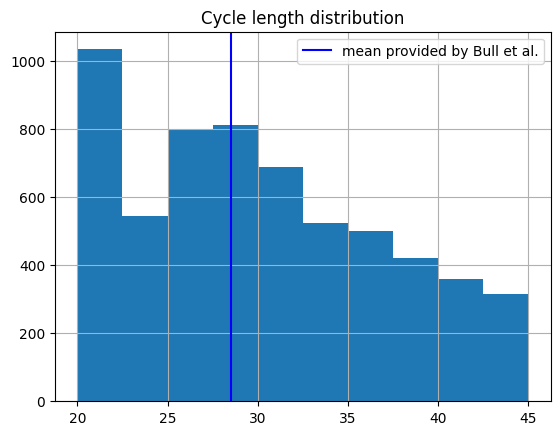

In [10]:
#2) exploring data characteristics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
synthetic_data['cycle_len'].hist()
plt.axvline(28.5, color = 'blue', label='mean provided by Bull et al.')
plt.legend()
plt.title('Cycle length distribution')

In [11]:
#2) handle missing values
print(synthetic_data.isnull().sum())
#all characteristics in the records are 0

user_id           0
cycle_no          0
cycle_len         0
follicular_len    0
luteal_len        0
irreg             0
bmi               0
sleep_hrs         0
stress_lvl        0
exercise_days     0
dysmenorrhea      0
p_irregular       0
source            0
dtype: int64


<Axes: >

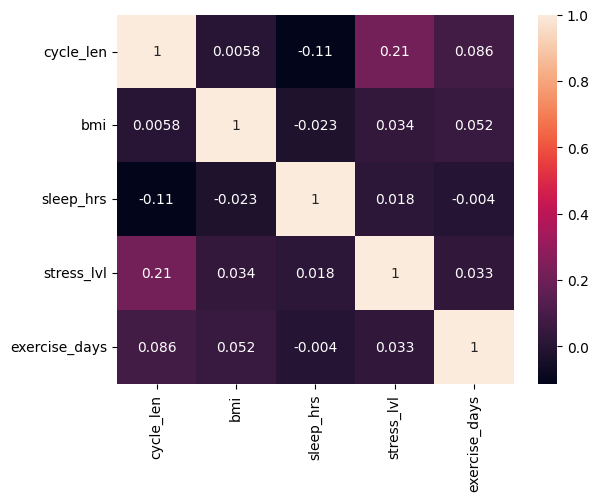

In [12]:
#3) correlation matrix
#testing id lifestyle variables actually correlate with cycle_length
sns.heatmap(synthetic_data[['cycle_len','bmi', 'sleep_hrs', 'stress_lvl', 'exercise_days']].corr(), annot=True)
#according to this heatmap, as BMI increases, cycle length increases; positive correlation: 0.0058
#as sleep hours increase, the cycle length decreases slightly. negative correlation: -0.11
#as stress level increases, the cycle length increases; positive correlation: 0.21
#as exercise days increases, the cycle length increases slightly; positive correlation: 0.086

In [13]:
#Confirming that the U-shape is actually a thing
synthetic_data['bmi_group'] = pd.cut(synthetic_data['bmi'], bins=[0,18.5,25,100], labels=['under', 'normal', 'over'])
synthetic_data.groupby('bmi_group')['irreg'].mean()

/tmp/ipykernel_1415/4172855768.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  synthetic_data.groupby('bmi_group')['irreg'].mean()


,irreg
bmi_group,
under,0.318273
normal,0.183732
over,0.266129


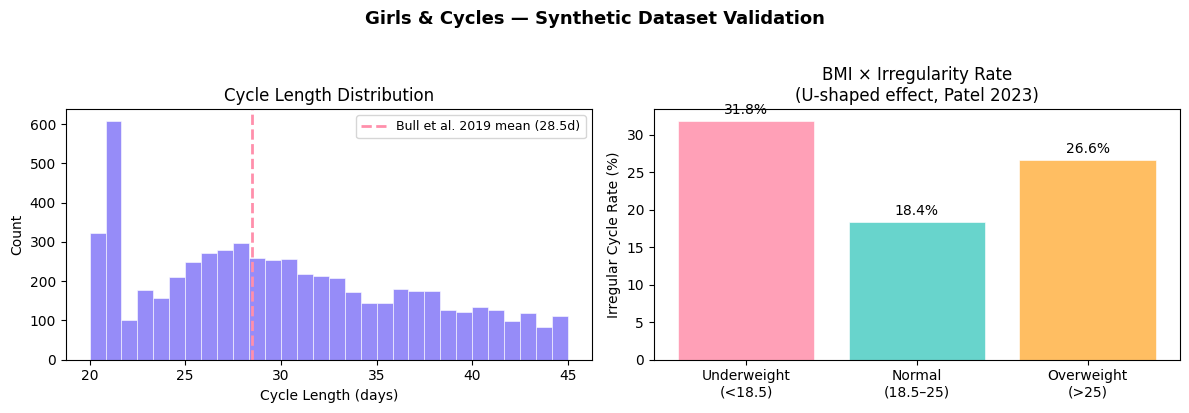

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Girls & Cycles — Synthetic Dataset Validation',
             fontsize=13, fontweight='bold', y=1.02)

# Plot 1: cycle length distribution vs literature
axes[0].hist(synthetic_data['cycle_len'], bins=30, color='#7C6FF7',
             alpha=0.8, edgecolor='white', linewidth=0.5)
axes[0].axvline(28.5, color='#FF8FAB', linewidth=2,
                linestyle='--', label='Bull et al. 2019 mean (28.5d)')
axes[0].set_xlabel('Cycle Length (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Cycle Length Distribution')
axes[0].legend(fontsize=9)

# Plot 2: U-shaped BMI irregularity effect
bmi_cats = ['Underweight\n(<18.5)', 'Normal\n(18.5–25)', 'Overweight\n(>25)']
irreg_rates = [
    synthetic_data[synthetic_data['bmi'] < 18.5]['irreg'].mean() * 100,
    synthetic_data[(synthetic_data['bmi'] >= 18.5) & (synthetic_data['bmi'] <= 25)]['irreg'].mean() * 100,
    synthetic_data[synthetic_data['bmi'] > 25]['irreg'].mean() * 100
]
colors = ['#FF8FAB', '#4ECDC4', '#FFB347']
bars = axes[1].bar(bmi_cats, irreg_rates, color=colors,
                    alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Irregular Cycle Rate (%)')
axes[1].set_title('BMI × Irregularity Rate\n(U-shaped effect, Patel 2023)')
for bar, rate in zip(bars, irreg_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='500')

plt.tight_layout()
plt.show()